In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_week1_outputs
from src.allocation_baseline import get_outstanding_shares
from src.backtest_engine import run_backtest

In [2]:
data = load_week1_outputs()
prices_pivot = data['prices_pivot']
pit_membership = data['pit_membership']
vn30_index = data['vn30_index']

full_universe = sorted(set().union(*pit_membership.values()))
outstanding_shares = get_outstanding_shares(full_universe)

rebalance_dates = pd.date_range(start='2021-01-01', end='2026-07-01', freq='QS')

Error fetching outstanding shares for ROS: 'outstanding_shares'


In [3]:
results, weights_history = run_backtest(
    rebalance_dates, prices_pivot, pit_membership, outstanding_shares, vn30_index,
    return_weights_history=True
)

Processing 2021-01-01...
Processing 2021-04-01...
Processing 2021-07-01...
Processing 2021-10-01...
Processing 2022-01-01...
Processing 2022-04-01...
Processing 2022-07-01...
Processing 2022-10-01...
Processing 2023-01-01...
Processing 2023-04-01...
Processing 2023-07-01...
Processing 2023-10-01...
Processing 2024-01-01...
Processing 2024-04-01...
Processing 2024-07-01...
Processing 2024-10-01...
Processing 2025-01-01...
Processing 2025-04-01...
Processing 2025-07-01...
Processing 2025-10-01...
Processing 2026-01-01...
Processing 2026-04-01...


In [4]:
results.to_csv('../data/processed/week5_baseline_results.csv')

In [7]:
# Calculate turnover
def compute_turnover_series(weights_history_strategy):
    dates = sorted(weights_history_strategy.keys())
    turnovers = []
    for i in range(1, len(dates)):
        old_w = weights_history_strategy[dates[i-1]]
        new_w = weights_history_strategy[dates[i]]
        all_symbols = set(old_w.index) | set(new_w.index)
        diff = new_w.reindex(all_symbols, fill_value=0) - old_w.reindex(all_symbols, fill_value=0)
        turnovers.append(diff.abs().sum() / 2)
    return pd.Series(turnovers, index=dates[1:])

In [8]:
turnover_table = {s: compute_turnover_series(weights_history[s]).mean() for s in weights_history}
print(pd.Series(turnover_table))

equal              0.020635
market_cap         0.059704
markowitz          0.352711
black_litterman    0.281317
dtype: float64


In [18]:
# Compute extended metrics: sortino, VaR, CVaR
def compute_extended_metrics(cumulative_series, drawdown_series, periods_per_year=4):
    returns = cumulative_series.pct_change().dropna()
    downside_returns = returns[returns < 0]
    sortino = (returns.mean() * periods_per_year - 0.035) / (downside_returns.std() * np.sqrt(periods_per_year))
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()

    return {'Sortino': sortino, 'VaR (95%)': var_95, 'CVaR (95%)': cvar_95}

In [16]:
extended_metrics = {}

for strategy in results.columns:
    extended_metrics[strategy] = compute_extended_metrics(results[strategy], None)

df_extended_metrics = pd.DataFrame(extended_metrics)
print(df_extended_metrics)

               equal  market_cap  markowitz  black_litterman
Sortino     0.737139    0.893573   0.583922         1.535603
VaR (95%)  -0.070662   -0.089517  -0.220491        -0.148664
CVaR (95%) -0.127130   -0.131082  -0.364157        -0.153369


Processing 2021-01-01...
Processing 2021-04-01...
Processing 2021-07-01...
Processing 2021-10-01...
Processing 2022-01-01...
Processing 2022-04-01...
Processing 2022-07-01...
Processing 2022-10-01...
Processing 2023-01-01...
Processing 2023-04-01...
Processing 2023-07-01...
Processing 2023-10-01...
Processing 2024-01-01...
Processing 2024-04-01...
Processing 2024-07-01...
Processing 2024-10-01...
Processing 2025-01-01...
Processing 2025-04-01...
Processing 2025-07-01...
Processing 2025-10-01...
Processing 2026-01-01...
Processing 2026-04-01...
Processing 2021-01-01...
Processing 2021-04-01...
Processing 2021-07-01...
Processing 2021-10-01...
Processing 2022-01-01...
Processing 2022-04-01...
Processing 2022-07-01...
Processing 2022-10-01...
Processing 2023-01-01...
Processing 2023-04-01...
Processing 2023-07-01...
Processing 2023-10-01...
Processing 2024-01-01...
Processing 2024-04-01...
Processing 2024-07-01...
Processing 2024-10-01...
Processing 2025-01-01...
Processing 2025-04-01...


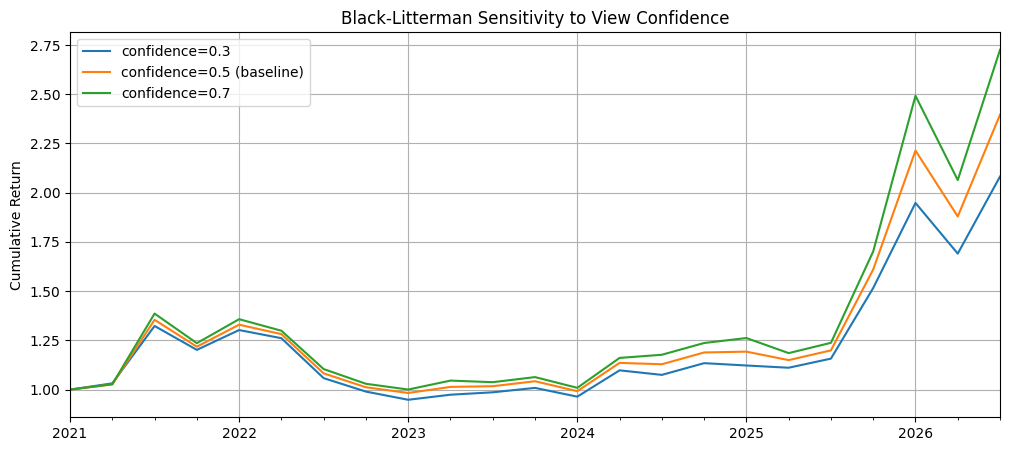

In [19]:
# Test the confidence sensitivity
results_low_conf, _ = run_backtest(
    rebalance_dates, prices_pivot, pit_membership, outstanding_shares, vn30_index,
    fixed_confidence=0.3, return_weights_history=True
)

results_high_conf, _ = run_backtest(
    rebalance_dates, prices_pivot, pit_membership, outstanding_shares, vn30_index,
    fixed_confidence=0.7, return_weights_history=True
)

comparison_confidence = pd.DataFrame({
    'confidence=0.3': results_low_conf['black_litterman'],
    'confidence=0.5 (baseline)': results['black_litterman'],
    'confidence=0.7': results_high_conf['black_litterman'],
})

comparison_confidence.plot(figsize=(12,5), title='Black-Litterman Sensitivity to View Confidence')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

*Comments:* The strategy demonstrates robustness in terms of trend orientation, yet the total final returns is sensitive with the set up view confidence.

In [20]:
# Correlation test
corr_vic_vhm = prices_pivot['VIC'].pct_change().corr(prices_pivot['VHM'].pct_change())
print(f"VIC-VHM return correlation: {corr_vic_vhm:.3f}")

VIC-VHM return correlation: 0.632


*Comment:* Although the Black-Litterman model effectively controls the HHI index, the stress-test results reveal potential hidden concentration risk. Specifically, the VIC - VHM stock pair maintains a high positive return correlation coefficient (0.632). This can be interpreted as the portfolio still being heavily influenced by ecosystem risk; if tail risk occurs at Vingroup, the diversification effectiveness of the portfolio will be reduced.

In [21]:
# Bootstrap sharpe CI
def bootstrap_sharpe_ci(returns, n_boot=1000, periods_per_year=4, rf=0.053):
    sharpes = []
    for _ in range(n_boot):
        sample = returns.sample(n=len(returns), replace=True)
        sharpe = (sample.mean() * periods_per_year - rf) / (sample.std() * np.sqrt(periods_per_year))
        sharpes.append(sharpe)
    return np.percentile(sharpes, [2.5, 97.5])

for strategy in results.columns:
    ci = bootstrap_sharpe_ci(results[strategy].pct_change().dropna())
    print(f"{strategy}: Sharpe 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")

equal: Sharpe 95% CI = [-0.551, 1.188]
market_cap: Sharpe 95% CI = [-0.507, 1.154]
markowitz: Sharpe 95% CI = [-0.558, 1.138]
black_litterman: Sharpe 95% CI = [-0.531, 1.225]


*Comment:*
- Not a very good result with overlapping and zero-crossing.
- The black-litterman does show the outstanding with highest upper limit (1.225), yet, still does not enough to guarantee to create the highest sharpe ratio at 95% confidence level
- As every strategies contain zero-crossing, with the current dataset, we does not have enough reason to ensure that these will consistenly deliver positive risk-adjusted returns in the future.